# CatBoost SHAP Feature Importance — Leakage-Safe Patient-Grouped Split

This notebook computes CatBoost SHAP feature importance for SIS and OHS prediction using a fixed 12 / 3 / 3 patient train / val / test split (seed = 42).

- **Model**: `CatBoostRegressor(iterations=1000, lr=0.1, depth=3, loss=RMSE)`
- **Preprocessing**: `StandardScaler → MinMaxScaler` fit on training rows only
- **Input rows**: raw daily sensor rows from `maison-llf-features.csv` (1 008 rows, 18 patients)
- **Targets**: SIS total, OHS total
- **SHAP computed on training set only** — no leakage from val / test patients

Two visualisations are produced for each target:
1. **Histogram** — mean |SHAP| per feature across all training rows (bar chart, top 20)
2. **Beeswarm** — per-sample SHAP values for all training rows (top 20 features)

CSVs of ranked feature importances are saved to `catboost-shap/` for use by the GRU notebook.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder

SEED     = 42
DATA_DIR = Path.cwd()
SHAP_DIR = DATA_DIR / 'catboost-shap'
SHAP_DIR.mkdir(exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
plt.style.use('ggplot')

SHAP_TARGETS = ['sis', 'ohs']
_pal = {'sis': 'steelblue', 'ohs': 'darkorange'}

_cb_kw = dict(
    iterations=1000, learning_rate=0.1, depth=3,
    loss_function='RMSE', verbose=False, random_seed=SEED,
)

## Data Loading and Feature Definitions

Feature columns are selected using the same modality prefixes as **modeling-daily.ipynb** (`acceleration`, `heartrate`, `motion`, `position`, `sleep`, `step`).  
`tug` and `chairstand` are excluded because they are concurrent clinical measures.

In [38]:
raw = pd.read_csv(
    DATA_DIR / 'data' / 'maison-llf-features.csv',
    parse_dates=['timestamp', 'clinical-timestamp'],
)
raw = raw.sort_values(['participant', 'timestamp', 'clinical-timestamp']).reset_index(drop=True)

sis_items     = [f'sis-{i:02d}' for i in range(1, 7)]
ohs_items     = [f'ohs-{i:02d}' for i in range(1, 13)]
oks_items     = [f'oks-{i:02d}' for i in range(1, 13)]
clinical_cols = sis_items + ohs_items + oks_items + ['sis', 'ohs', 'oks', 'tug', 'chairstand']
id_cols       = ['participant', 'timestamp', 'clinical-timestamp']
sensor_cols   = [c for c in raw.columns if c not in id_cols + clinical_cols]

print(f'rows={len(raw)}, patients={raw["participant"].nunique()}, sensor_cols={len(sensor_cols)}')
print(sensor_cols)

rows=1008, patients=18, sensor_cols=46
['acceleration-count', 'acceleration-mean', 'acceleration-std', 'acceleration-sum', 'acceleration-entropy', 'acceleration-kurtosis', 'acceleration-skew', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-movement-events-24h', 'acceleration-intradaily-variability', 'heartrate-count', 'heartrate-min', 'heartrate-max', 'heartrate-mean', 'heartrate-std', 'heartrate-hours-with-data', 'motion-count', 'motion-ratio', 'motion-mean', 'motion-max', 'motion-max-timestamp', 'position-count', 'position-duration', 'position-distance-travelled', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-duration-to-wakeup', 'sleep-wakeup-count', 'sleep-heartrate-mean', 'sleep-heartrate-min',

## Train / Val / Test Split

Patients are shuffled (seed=42) and split 12 / 3 / 3 into train, validation, and test sets. Every daily row for a given patient stays entirely within one partition.

In [39]:
all_pts  = np.array(sorted(raw['participant'].unique()))
rng      = np.random.default_rng(SEED)
shuffled = all_pts.copy()
rng.shuffle(shuffled)

train_pts = shuffled[:12]
val_pts   = shuffled[12:15]
test_pts  = shuffled[15:]

def idx_for_patients(pts):
    return np.where(raw['participant'].isin(pts))[0]

train_ids = idx_for_patients(train_pts)
val_ids   = idx_for_patients(val_pts)
test_ids  = idx_for_patients(test_pts)

display(pd.DataFrame([
    {'split': 'train', 'patients': sorted(train_pts.tolist()), 'n_rows': len(train_ids)},
    {'split': 'val',   'patients': sorted(val_pts.tolist()),   'n_rows': len(val_ids)},
    {'split': 'test',  'patients': sorted(test_pts.tolist()),  'n_rows': len(test_ids)},
]))

,split,patients,n_rows
0,train,"[1, 4, 6, 7, 8, 10, 11, 12, 13, 15, 17, 18]",672
1,val,"[3, 5, 16]",168
2,test,"[2, 9, 14]",168


## Sensor SHAP — CatBoost (Training Set Only)

1. Median-impute NaN values using training-set statistics only
2. `StandardScaler` → `MinMaxScaler` fit on training rows only
3. Train `CatBoostRegressor` with early stopping on training loss
4. `shap.TreeExplainer` on training rows

In [ ]:
train = raw.iloc[train_ids]
med   = train[sensor_cols].median()
Xr    = train[sensor_cols].fillna(med).values.astype(np.float32)
X     = MinMaxScaler().fit_transform(StandardScaler().fit_transform(Xr))

sensor_shap_vals = {}
sensor_shap_X    = {}

for target in SHAP_TARGETS:
    m = CatBoostRegressor(**_cb_kw)
    m.fit(X, train[target].values, eval_set=(X, train[target].values),
          use_best_model=True, early_stopping_rounds=100)
    sv = shap.TreeExplainer(m).shap_values(X)
    sensor_shap_vals[target] = sv
    sensor_shap_X[target]    = X

sensor_shap_dfs = {}
for target in SHAP_TARGETS:
    avg = np.abs(sensor_shap_vals[target]).mean(axis=0)
    df  = (pd.DataFrame({'feature': sensor_cols, 'weights': avg})
             .sort_values('weights', ascending=False)
             .reset_index(drop=True))
    sensor_shap_dfs[target] = df
    df.to_csv(SHAP_DIR / f'shap_catboost_{target}_feature_importance.csv', index=False)
    print(f'{target.upper()} top-5: {df["feature"].head(5).tolist()}')

print('\nSensor SHAP CSVs saved to', SHAP_DIR)

### Sensor Feature Importance — Histogram (Top 20)

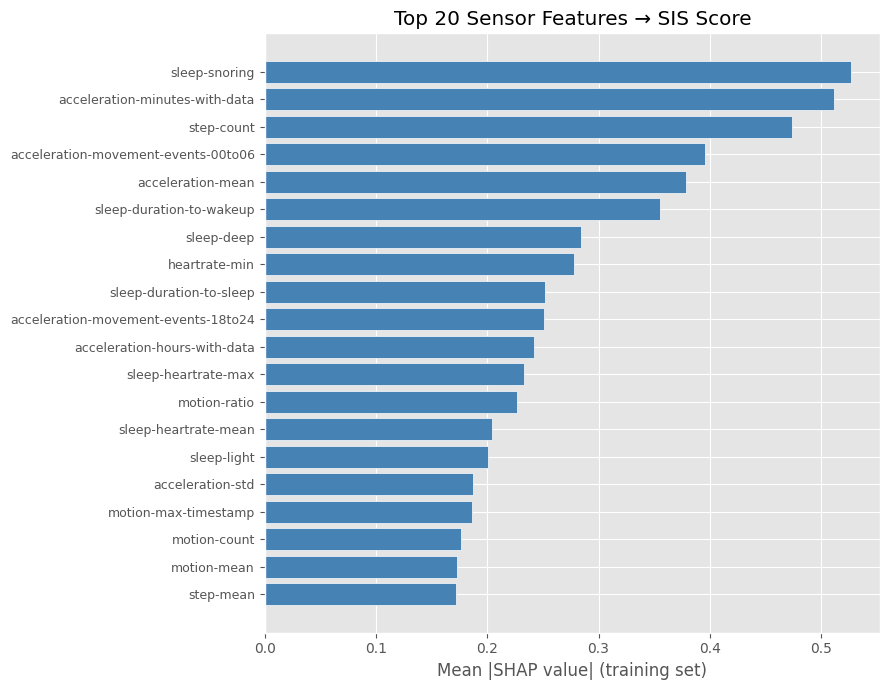

Saved: shap_catboost_sensor_sis_top20.png


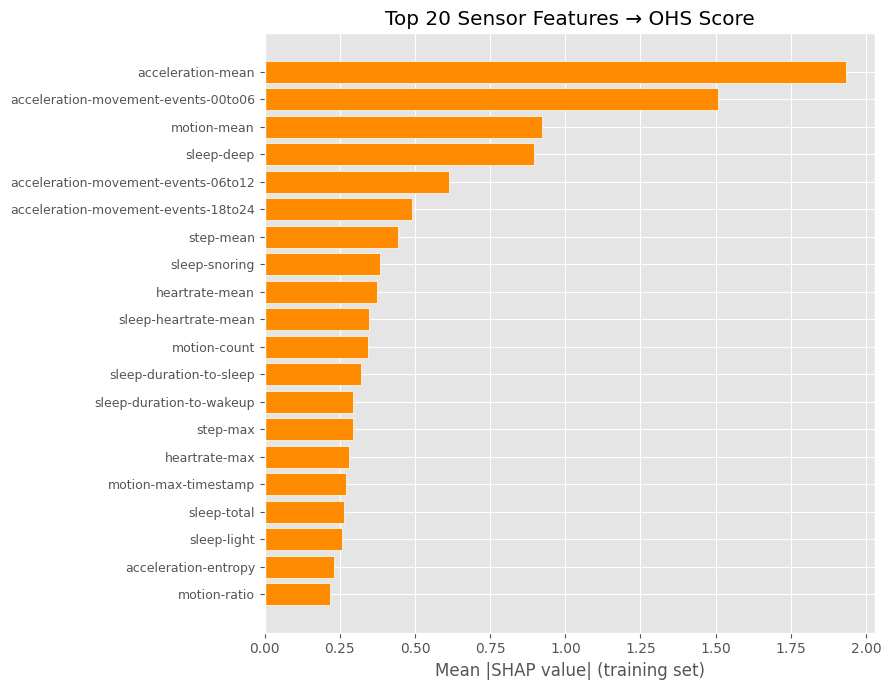

Saved: shap_catboost_sensor_ohs_top20.png


In [41]:
for target in SHAP_TARGETS:
    top20 = sensor_shap_dfs[target].head(20)
    fig, ax = plt.subplots(figsize=(9, 7))
    y_pos = np.arange(len(top20))
    ax.barh(y_pos, top20['weights'].values[::-1],
            color=_pal[target], edgecolor='white', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top20['feature'].values[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP value| (training set)')
    ax.set_title(f'Top 20 Sensor Features → {target.upper()} Score')
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'shap_catboost_sensor_{target}_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: shap_catboost_sensor_{target}_top20.png')

### Sensor Feature Importance — Beeswarm (Top 20)

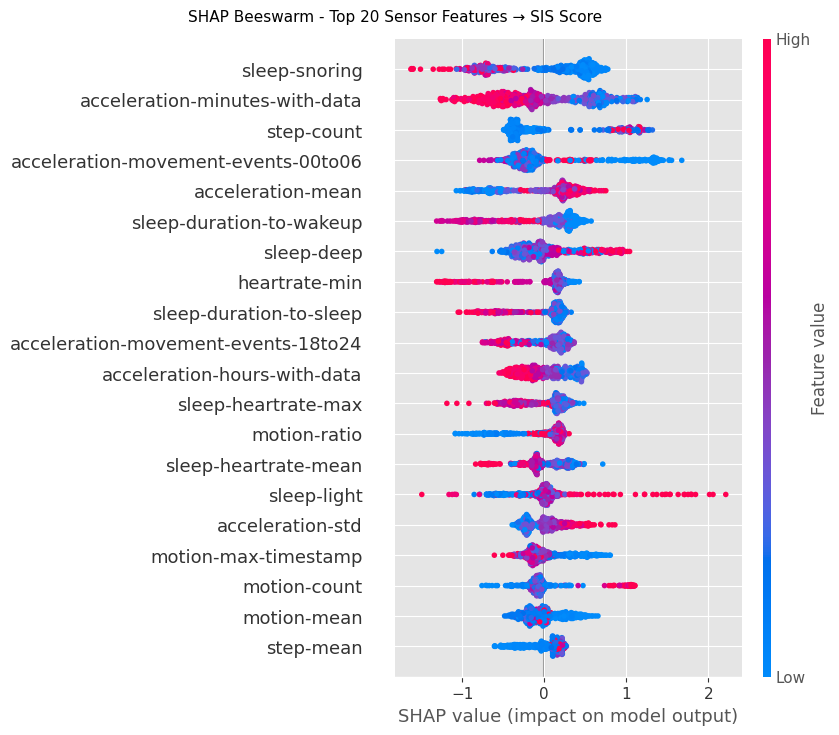

Saved: shap_catboost_sensor_sis_beeswarm.png


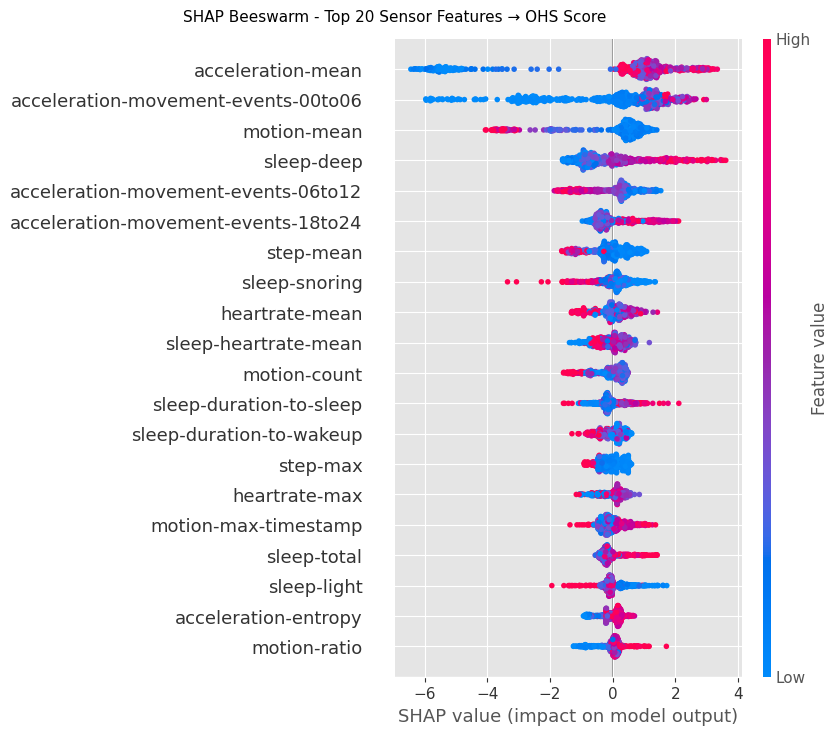

Saved: shap_catboost_sensor_ohs_beeswarm.png


In [ ]:
for target in SHAP_TARGETS:
    top20_feat = sensor_shap_dfs[target]['feature'].head(20).tolist()
    top20_idx  = [sensor_cols.index(f) for f in top20_feat]
    sv_pool    = sensor_shap_vals[target][:, top20_idx]
    X_pool     = sensor_shap_X[target][:, top20_idx]
    n_rows     = sv_pool.shape[0]

    shap.summary_plot(sv_pool, X_pool, feature_names=top20_feat, max_display=20, show=False)
    fig = plt.gcf()
    fig.set_size_inches(9, 7)
    fig.suptitle(
        f'SHAP - Top 20 Sensor Features → {target.upper()} Score\n',
        fontsize=11, y=1.02,
    )
    plt.savefig(DATA_DIR / f'shap_catboost_sensor_{target}_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: shap_catboost_sensor_{target}_beeswarm.png')

## Demographic SHAP — CatBoost (Training Set Only)

Categorical demographic features are ordinal-encoded before the `StandardScaler` → `MinMaxScaler` pipeline. The same train / val / test split is used.

In [ ]:
demo_raw_df    = pd.read_csv(DATA_DIR / 'data' / 'maison-llf-demographics.csv')
demo_feat_cols = ['sex', 'age', 'fracture-type', 'relationship', 'education', 'work', 'ethnicity']
_cat_cols      = [c for c in demo_feat_cols if c != 'age']

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
demo_encoded = demo_raw_df.copy()
demo_encoded[_cat_cols] = enc.fit_transform(demo_raw_df[_cat_cols].astype(str))

demo_daily = raw[['participant', 'sis', 'ohs']].copy()
demo_daily = demo_daily.merge(
    demo_encoded[['participant'] + demo_feat_cols], on='participant', how='left'
)

train_demo = demo_daily.iloc[train_ids]
med_demo   = train_demo[demo_feat_cols].median()
Xr_demo    = train_demo[demo_feat_cols].fillna(med_demo).values.astype(np.float32)
X_demo     = MinMaxScaler().fit_transform(StandardScaler().fit_transform(Xr_demo))

demo_shap_vals = {}
demo_shap_X    = {}

for target in SHAP_TARGETS:
    m = CatBoostRegressor(**_cb_kw)
    m.fit(X_demo, train_demo[target].values,
          eval_set=(X_demo, train_demo[target].values),
          use_best_model=True, early_stopping_rounds=100)
    sv = shap.TreeExplainer(m).shap_values(X_demo)
    demo_shap_vals[target] = sv
    demo_shap_X[target]    = X_demo
    print(f'{target.upper()} done')

demo_shap_dfs = {}
for target in SHAP_TARGETS:
    avg = np.abs(demo_shap_vals[target]).mean(axis=0)
    df  = (pd.DataFrame({'feature': demo_feat_cols, 'weights': avg})
             .sort_values('weights', ascending=False)
             .reset_index(drop=True))
    demo_shap_dfs[target] = df
    df.to_csv(SHAP_DIR / f'shap_catboost_demo_{target}_feature_importance.csv', index=False)
    print(f'\n{target.upper()} demographic SHAP:')
    print(df.to_string(index=False))

print('\nDemographic SHAP CSVs saved to', SHAP_DIR)

### Demographic Feature Importance — Individual Histograms + Side-by-Side

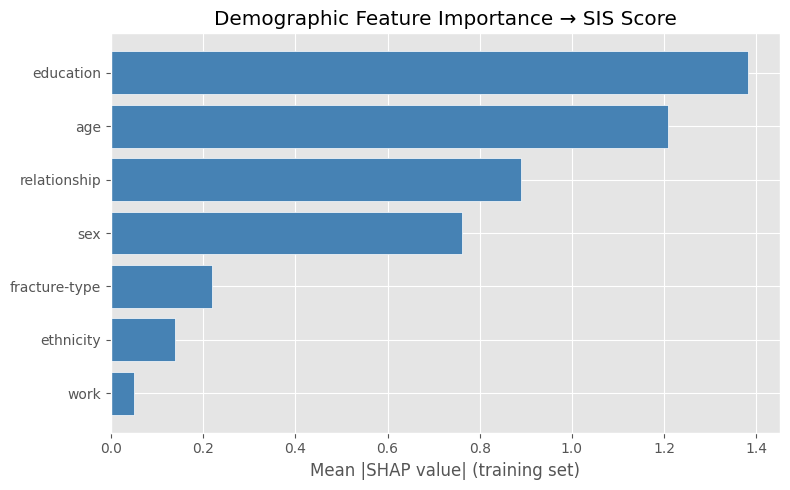

Saved: shap_catboost_demo_sis.png


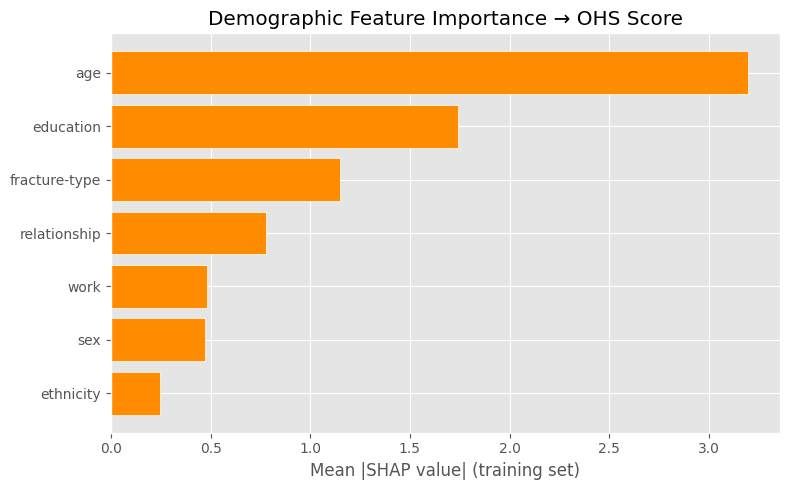

Saved: shap_catboost_demo_ohs.png


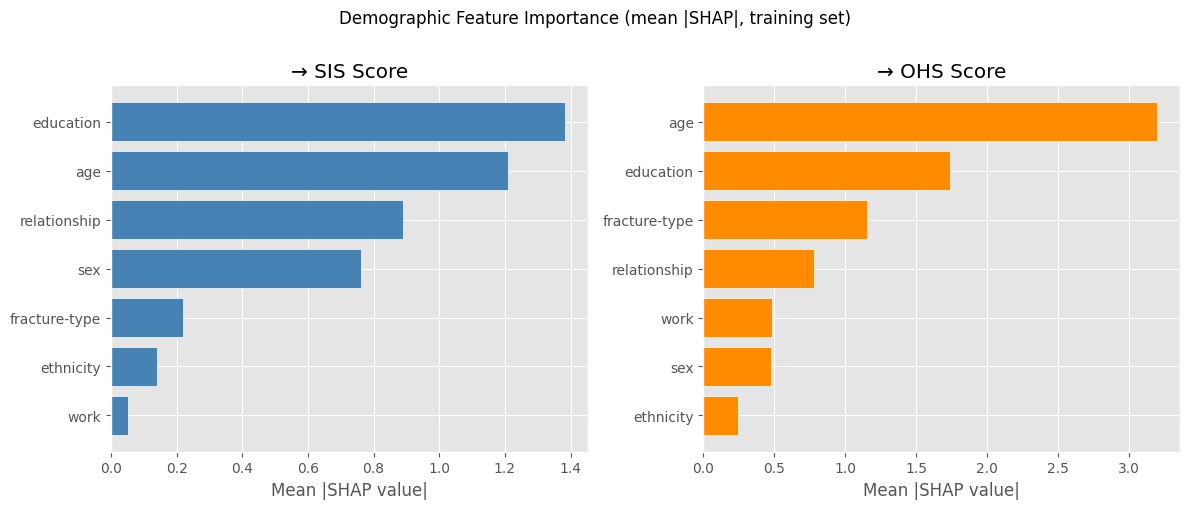

Saved: shap_catboost_demo_combined.png


In [44]:
for target in SHAP_TARGETS:
    df = demo_shap_dfs[target]
    fig, ax = plt.subplots(figsize=(8, 5))
    y_pos = np.arange(len(df))
    ax.barh(y_pos, df['weights'].values[::-1],
            color=_pal[target], edgecolor='white', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['feature'].values[::-1], fontsize=10)
    ax.set_xlabel('Mean |SHAP value| (training set)')
    ax.set_title(f'Demographic Feature Importance → {target.upper()} Score')
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'shap_catboost_demo_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: shap_catboost_demo_{target}.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, target in zip(axes, SHAP_TARGETS):
    df = demo_shap_dfs[target]
    y_pos = np.arange(len(df))
    ax.barh(y_pos, df['weights'].values[::-1],
            color=_pal[target], edgecolor='white', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['feature'].values[::-1], fontsize=10)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'→ {target.upper()} Score')
fig.suptitle(
    'Demographic Feature Importance (mean |SHAP|, training set)',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_catboost_demo_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_catboost_demo_combined.png')

### Demographic Feature Importance — Beeswarm

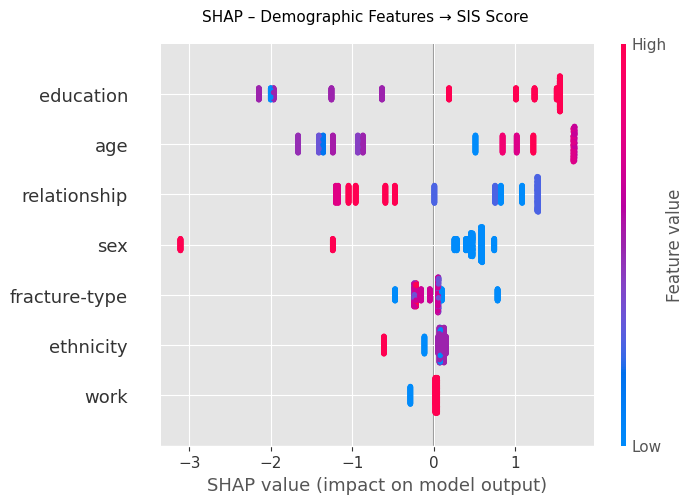

Saved: shap_catboost_demo_sis_beeswarm.png


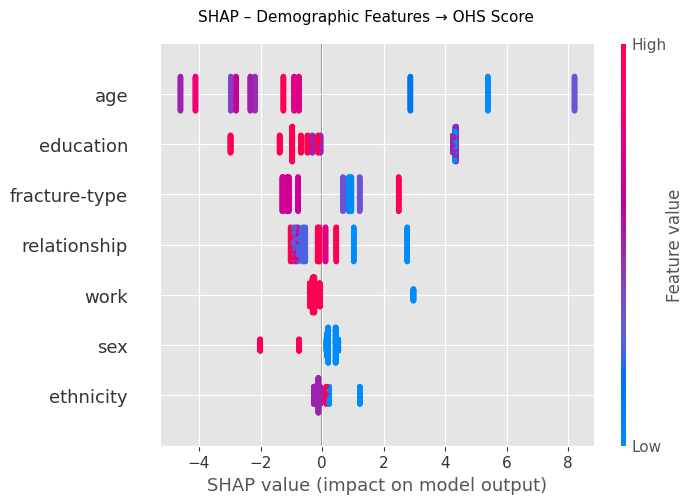

Saved: shap_catboost_demo_ohs_beeswarm.png


In [45]:
for target in SHAP_TARGETS:
    sv_pool = demo_shap_vals[target]
    X_pool  = demo_shap_X[target]
    n_rows  = sv_pool.shape[0]

    shap.summary_plot(sv_pool, X_pool, feature_names=demo_feat_cols,
                      max_display=len(demo_feat_cols), show=False)
    fig = plt.gcf()
    fig.set_size_inches(7, 5)
    fig.suptitle(
        f'SHAP – Demographic Features → {target.upper()} Score\n',
        fontsize=11, y=1.02,
    )
    plt.savefig(DATA_DIR / f'shap_catboost_demo_{target}_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: shap_catboost_demo_{target}_beeswarm.png')